# Análisis de Series Temporales
---
Eduardo González Gutiérrez
## Descripción


## Carga de librerías

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


In [11]:
# Cargamos los datos
df = pd.read_csv('Series1-6.csv', sep=';', decimal=',')

# Visualizamos las columnas del dataset
print(df.head())
print(df.columns)

   Serie1  Serie2  Serie3  Serie4  Serie5  Serie6
0   2.538   0.296  -0.186   0.931  -6.319   0.955
1   3.834   1.201  -0.185  -0.707  -6.384  -1.827
2  -0.259   1.090   0.964  -0.767  -5.371  -1.438
3   2.862  -0.359  -1.249  -2.581  -5.330   0.269
4   2.319  -0.130  -0.396  -1.101  -7.233   0.781
Index(['Serie1', 'Serie2', 'Serie3', 'Serie4', 'Serie5', 'Serie6'], dtype='object')


## Análisis Serie 1

ANÄLISI

Text(0, 0.5, 'Valor')

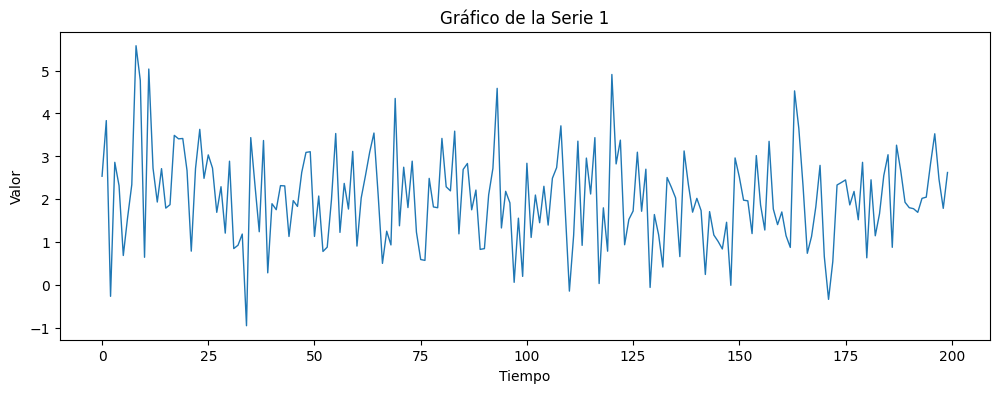

In [ ]:
# Seleccionamos la Serie 1
serie1 = df['Serie1']

# Visualizamos la serie
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie1, linewidth=1)
ax.set_title('Gráfico de la Serie 1')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show();

In [30]:
# Convertir a numérico los datos con errores
serie1 = pd.to_numeric(df['Serie1'], errors='coerce')
print("Tipo de los datos {serie1.dtype}")

# Eliminamos los valores Nan de la serie
print(f"NaN en serie1: {serie1.isna().sum()}")
serie1_clean = serie1.dropna()

Tipo de los datos {serie1.dtype}
NaN en serie1: 1800


In [20]:
# Paso 3 - Test ADF
resultado_adf = adfuller(serie1_clean, maxlag=25)  # 25 lags para Serie 1

print("=== Test ADF - Serie 1 ===")
print(f"Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"p-valor         : {resultado_adf[1]:.4f}")
print(f"Lags usados     : {resultado_adf[2]}")
print(f"Observaciones   : {resultado_adf[3]}")
print("\nValores críticos:")
for nivel, valor in resultado_adf[4].items():
    print(f"  {nivel}: {valor:.4f}")

# Interpretación automática
print("\nInterpretación")
if resultado_adf[1] < 0.05:
    print("p-valor < 0.05, se rechaza H0 y la serie ES estacionaria")
else:
    print("p-valor ≥ 0.05, no se rechaza H0 por lo que la serie NO ES estacionaria. Hay que aplicar transformación para hacerla estacionaria")

=== Test ADF - Serie 1 ===
Estadístico ADF : -8.3766
p-valor         : 0.0000
Lags usados     : 2
Observaciones   : 197

Valores críticos:
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747

Interpretación
p-valor < 0.05, se rechaza H0 y la serie ES estacionaria


=== Normalidad - Serie 1 ===
Shapiro-Wilk estadístico : 0.9914
p-valor                  : 0.2793
Asimetría (skewness)     : 0.2604
Curtosis (kurtosis)      : 0.3438


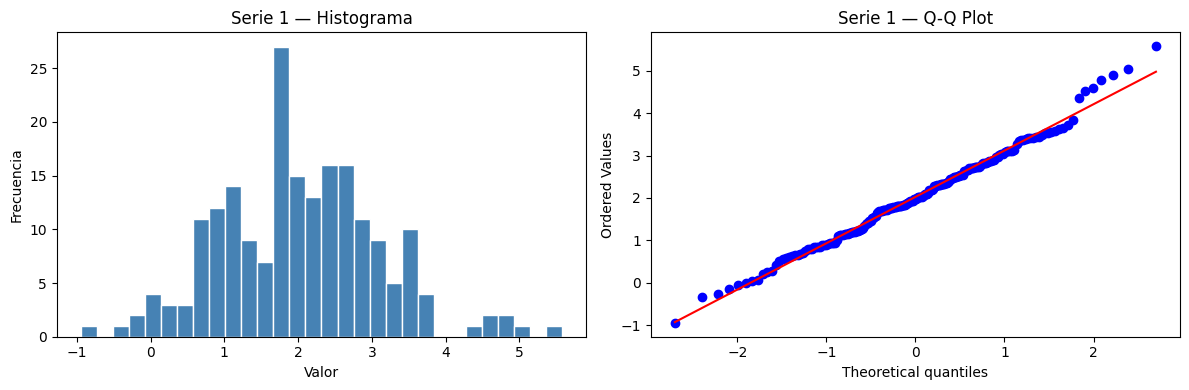


--- Interpretación ---
✅ p-valor ≥ 0.05 → No se rechaza normalidad → La serie sigue una distribución normal


In [ ]:
# Normalidad
print("Normalidad - Serie 1")

# Test de Shapiro-Wilk
stat, p_valor = stats.shapiro(serie1_clean)
print(f"Shapiro-Wilk estadístico : {stat:.4f}")
print(f"p-valor                  : {p_valor:.4f}")

# Asimetría y curtosis
print(f"Asimetría (skewness)     : {stats.skew(serie1_clean):.4f}")
print(f"Curtosis (kurtosis)      : {stats.kurtosis(serie1_clean):.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(serie1_clean, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Serie 1 — Histograma')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(serie1_clean, dist="norm", plot=axes[1])
axes[1].set_title('Serie 1 — Q-Q Plot')

plt.tight_layout()
plt.show()

# Interpretación
print("\n--- Interpretación ---")
if p_valor < 0.05:
    print("p-valor < 0.05, se rechaza normalidad por lo que la serie NO sigue una distribución normal")
else:
    print("p-valor ≥ 0.05, no se rechaza normalidad por lo que la serie sigue una distribución normal")

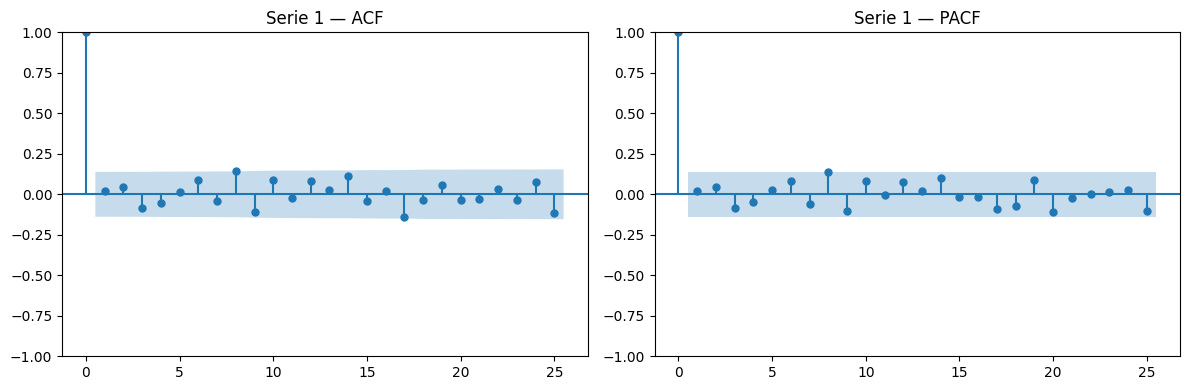

=== Ljung-Box - Serie 1 ===
      lb_stat  lb_pvalue
1    0.073708   0.786013
2    0.510710   0.774641
3    1.891875   0.595149
4    2.428669   0.657453
5    2.487033   0.778447
6    4.040201   0.671236
7    4.432537   0.728825
8    8.605508   0.376659
9   11.224636   0.260625
10  12.836047   0.232984
11  12.930339   0.297903
12  14.408017   0.275415
13  14.531213   0.337524
14  17.267407   0.242208
15  17.593560   0.284636
16  17.667494   0.343724
17  21.913424   0.188071
18  22.230602   0.221908
19  22.963518   0.238953
20  23.258376   0.276287
21  23.439589   0.320996
22  23.641745   0.366285
23  23.921426   0.408170
24  25.189652   0.395514
25  28.263155   0.295882

--- Interpretación ---
✅ Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco


In [32]:
# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(serie1_clean, lags=25, ax=axes[0])
axes[0].set_title('Serie 1 — ACF')

plot_pacf(serie1_clean, lags=25, ax=axes[1])
axes[1].set_title('Serie 1 — PACF')

plt.tight_layout()
plt.show()

# Test de Ljung-Box
lb = acorr_ljungbox(serie1_clean, lags=25, return_df=True)
print("=== Ljung-Box - Serie 1 ===")
print(lb)

# Interpretación
print("\n--- Interpretación ---")
if (lb['lb_pvalue'] < 0.05).any():
    print("❌ Algún p-valor < 0.05 → Existe autocorrelación significativa → La serie NO es ruido blanco")
else:
    print("✅ Todos los p-valores ≥ 0.05 → No hay autocorrelación → La serie ES ruido blanco")